# 01 — Data Exploration
**Week 2 deliverable: California Property Close Price Prediction**

Goal: load at least 6 months of `CRMLSSold` files, restrict to
`PropertyType = "Residential"` and `PropertySubType = "SingleFamilyResidence"`,
and explore the target (`ClosePrice`) and key features.

> Before running: check `Trestle Property MetaData.pdf` and rename any columns below
> that don't match your actual files (column names can vary slightly by MLS export).


In [2]:
import glob
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


## 1. Load all downloaded CRMLSSold files (6+ months)

In [4]:
# Point this at the local folder where you downloaded the CRMLSSold files via FileZilla
DATA_DIR = "C:/Users/thanh/Downloads"  # <-- update to your local path

files = sorted(glob.glob(os.path.join(DATA_DIR, "CRMLSSold*")))
print(f"Found {len(files)} files:")
for f in files:
    print(" -", os.path.basename(f))

assert len(files) >= 6, "Task requires a minimum of 6 months of data — check DATA_DIR."


Found 30 files:
 - CRMLSSold20220101_20231231_filled.csv
 - CRMLSSold202401_filled.csv
 - CRMLSSold202402_filled.csv
 - CRMLSSold202403_filled.csv
 - CRMLSSold202404_filled.csv
 - CRMLSSold202405_filled.csv
 - CRMLSSold202406_filled.csv
 - CRMLSSold202407_filled.csv
 - CRMLSSold202408.csv
 - CRMLSSold202409.csv
 - CRMLSSold202410.csv
 - CRMLSSold202411.csv
 - CRMLSSold202412.csv
 - CRMLSSold202501_filled.csv
 - CRMLSSold202502.csv
 - CRMLSSold202503.csv
 - CRMLSSold202504.csv
 - CRMLSSold202505.csv
 - CRMLSSold202506.csv
 - CRMLSSold202507.csv
 - CRMLSSold202508.csv
 - CRMLSSold202509.csv
 - CRMLSSold202510.csv
 - CRMLSSold202511.csv
 - CRMLSSold202512.csv
 - CRMLSSold202601.csv
 - CRMLSSold202602.csv
 - CRMLSSold202603.csv
 - CRMLSSold202604.csv
 - CRMLSSold202605.csv


In [5]:
dfs = []
for f in files:
    tmp = pd.read_csv(f, low_memory=False)
    tmp["__source_file"] = os.path.basename(f)
    dfs.append(tmp)

df_raw = pd.concat(dfs, ignore_index=True)
print(df_raw.shape)
df_raw.head()


(794271, 83)


,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,BuyerAgencyCompensationType,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,__source_file,BuyerAgentAOR,ListAgentAOR
0,"Carpet,Wood",True,NaN,NaN,True,98000.0,556366533,michellefsellsoc@gmail.com,2022-02-25,95000.0,Michelle,Fairchild,33.699517,-117.960655,231 Albatross Lane,ManufacturedInPark,1368.0,98000.0,86.0,Premiere Choice R E Inc,Premiere Choice R E Inc,Premiere Choice R E Inc,Michelle Fairchild,Josh,Lukasiewicz,ocfairmic,Michelle,Fairchild,NaN,NaN,NaN,556366533.0,16 - Fountain Valley / Northeast HB,NaN,Orange,Closed,NaN,NaN,2.0,NaN,NaN,NaN,Rancho la Siesta 55+ Senior,OrangeCounty,1969.0,Item,231.0,OC21227682,2.0,Fountain Valley,1500.00,NaN,NaN,2.0,2022-02-25,NaN,NaN,2022-01-28,2021-10-13,NaN,NaN,CA,NaN,NaN,NaN,1.0,NaN,One,NaN,NaN,NaN,NaN,0.0,ABC Unified,92708,0.0,NaN,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN
1,NaN,False,NaN,NaN,False,1200.0,556366530,dineshcalre@gmail.com,2022-02-19,1200.0,DINESH,MAYANI,34.497691,-117.192323,21601 Powhatan Road 2,ResidentialLease,850.0,1200.0,125.0,California Real Estate & Investments,California Real Estate & Investments,NaN,DINESH MAYANI,NaN,NaN,evmayadin,DINESH,MAYANI,NaN,NaN,NaN,556366530.0,APPV - Apple Valley,NaN,San Bernardino,Closed,NaN,False,1.0,NaN,Apartment,0.9871,NaN,EastValley,1987.0,Item,21601.0,EV21227683,1.0,Apple Valley,100.00,NaN,NaN,2.0,2022-02-19,NaN,NaN,2022-02-19,2021-10-13,NaN,NaN,CA,NaN,NaN,False,1.0,NaN,One,NaN,43000.0,2.0,False,1.0,Apple Valley Unified,92308,0.0,43000.0,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN
2,NaN,True,NaN,NaN,False,1100000.0,556366044,cindydavishomes@gmail.com,2022-04-15,1100000.0,Cindy,Davis,32.981292,-117.262529,827 Del Mar Downs Rd. D,Residential,1344.0,1100000.0,106.0,SD Home Source Realty,Compass,NaN,Cindy Davis,NaN,NaN,SAND-646850,Lindsay,Dunlap,NaN,Monthly,NaN,556366044.0,92075 - Solana Beach,NaN,San Diego,Closed,NaN,True,2.0,NaN,Townhouse,NaN,NaN,SanDiego,1974.0,Item1,827.0,NDP2111697,3.0,Solana Beach,1.50,NaN,NaN,3.0,2022-04-15,NaN,NaN,2022-02-03,2021-10-13,NaN,NaN,CA,NaN,NaN,True,2.0,NaN,Two,NaN,NaN,0.0,NaN,1.0,Solana Beach,92075,370.0,NaN,NaN,False,False,CRMLSSold20220101_20231231_filled.csv,NaN,NaN
3,NaN,True,NaN,NaN,False,2499999.0,556365765,bryanmeathe@gmail.com,2022-01-04,2499999.0,Bryan,Meathe,33.147270,-117.340604,295 Chinquapin Ave,Residential,2645.0,2499999.0,37.0,Coldwell Banker Realty,ERA Ranch & Sea Realty,NaN,Bryan Meathe,NaN,NaN,101046,Bill,Kellaway,NaN,Monthly,NaN,556365765.0,92008 - Carlsbad,NaN,San Diego,Closed,NaN,True,2.0,NaN,SingleFamilyResidence,0.3071,NaN,NorthSanDiegoCounty,2016.0,Item1,295.0,NDP2111696,4.0,Carlsbad,2.25,NaN,NaN,4.0,2022-01-04,NaN,NaN,2021-11-19,2021-10-13,NaN,NaN,CA,NaN,NaN,False,NaN,NaN,ThreeOrMore,NaN,13376.0,0.0,NaN,2.0,Carlsbad Unified,92008,140.0,13376.0,NaN,False,False,CRMLSSold20220101_20231231_filled.

## 2. Filter to Residential / Single Family per task spec

In [7]:
df = df_raw[
    (df_raw["PropertyType"] == "Residential")
    & (df_raw["PropertySubType"] == "SingleFamilyResidence")
].copy()

print(f"Rows before filter: {len(df_raw):,}")
print(f"Rows after filter:  {len(df):,}")


Rows before filter: 794,271
Rows after filter:  399,157


## 3. Structure check
Shape, dtypes, missing values — this drives your Week 3 preprocessing decisions.

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 399157 entries, 3 to 794267
Data columns (total 83 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      256352 non-null  object 
 1   ViewYN                        359640 non-null  object 
 2   WaterfrontYN                  175 non-null     object 
 3   BasementYN                    9747 non-null    object 
 4   PoolPrivateYN                 358610 non-null  object 
 5   OriginalListPrice             398378 non-null  float64
 6   ListingKey                    399157 non-null  int64  
 7   ListAgentEmail                398296 non-null  object 
 8   CloseDate                     399157 non-null  object 
 9   ClosePrice                    399155 non-null  float64
 10  ListAgentFirstName            395752 non-null  object 
 11  ListAgentLastName             399120 non-null  object 
 12  Latitude                      398964 non-null  fl

In [10]:
missing = (
    df.isna().mean().sort_values(ascending=False) * 100
).round(2)
missing[missing > 0].to_frame("pct_missing")


,pct_missing
AboveGradeFinishedArea,100.00
CoveredSpaces,100.00
FireplacesTotal,100.00
TaxYear,100.00
ElementarySchoolDistrict,100.00
...,...
BuyerAgentLastName,0.04
PurchaseContractDate,0.04
ListAgentFullName,0.02
BathroomsTotalInteger,0.02


## 4. Target variable: ClosePrice

count    3.991550e+05
mean     1.285092e+06
std      5.237207e+06
min      0.000000e+00
25%      6.200000e+05
50%      8.890000e+05
75%      1.425000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64


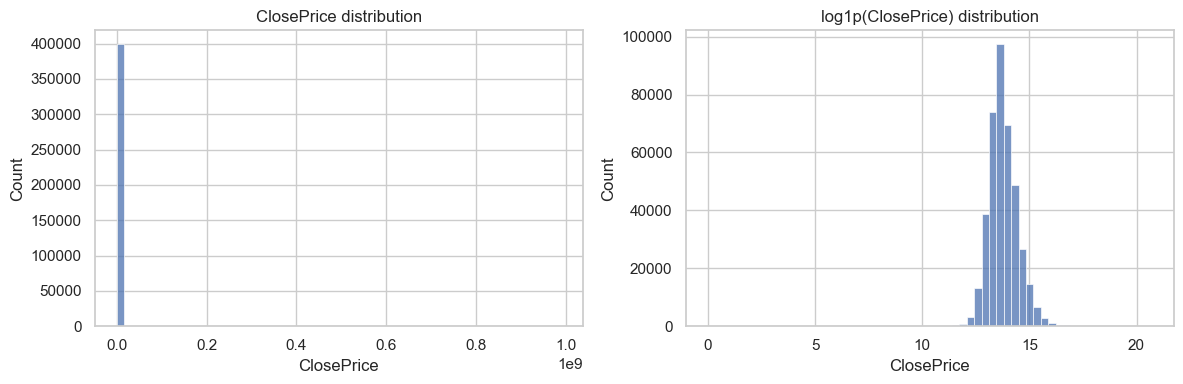

In [12]:
print(df["ClosePrice"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["ClosePrice"], bins=60, ax=axes[0])
axes[0].set_title("ClosePrice distribution")

sns.histplot(np.log1p(df["ClosePrice"]), bins=60, ax=axes[1])
axes[1].set_title("log1p(ClosePrice) distribution")
plt.tight_layout()
plt.show()


ClosePrice is almost always right-skewed with a long tail of high-end sales.
Note in your writeup whether a log transform looks more model-friendly than raw price.

## 5. Key features: LivingArea, Bedrooms, Bathrooms, LotSize

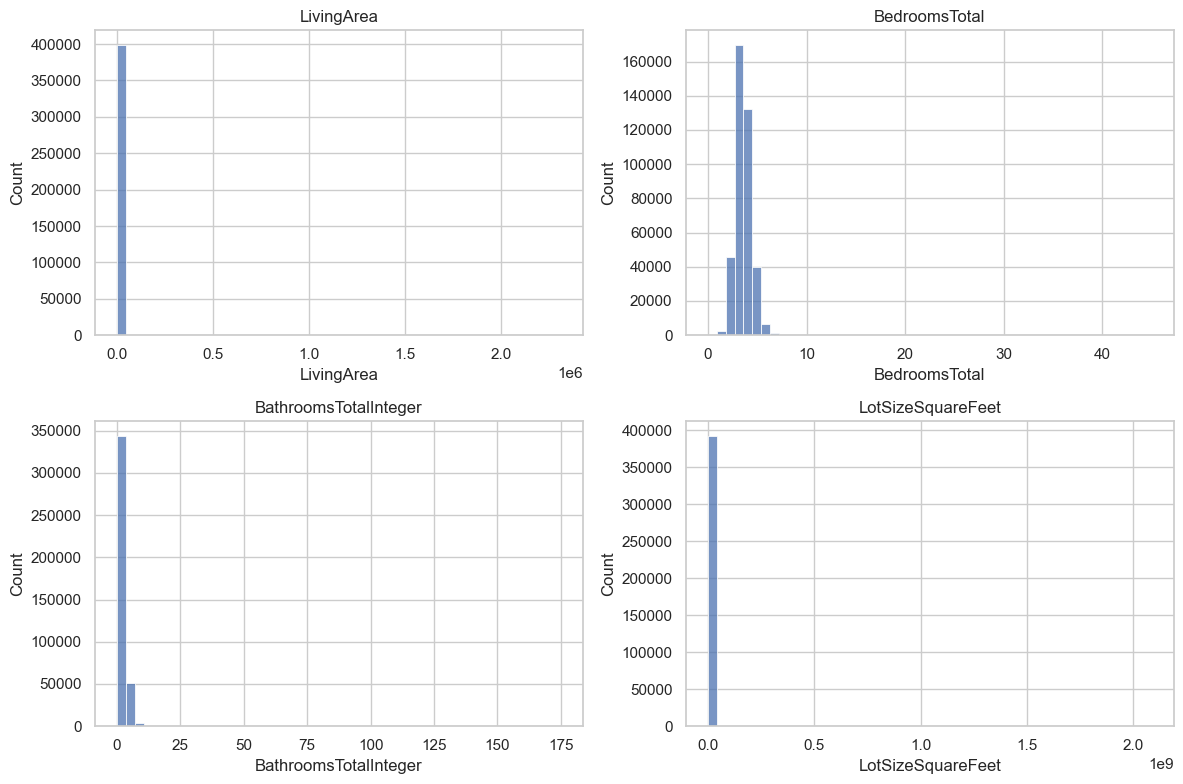

In [15]:
# Adjust these names if your metadata doc uses different labels
feature_cols = ["LivingArea", "BedroomsTotal", "BathroomsTotalInteger", "LotSizeSquareFeet"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.histplot(df[col].dropna(), bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [16]:
df[feature_cols + ["ClosePrice"]].describe()


,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet,ClosePrice
count,3.989470e+05,399157.000000,399082.000000,3.923310e+05,3.991550e+05
mean,2.036718e+03,3.476710,2.610133,2.454994e+05,1.285092e+06
std,3.803275e+03,0.960517,1.182700,1.387443e+07,5.237207e+06
min,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,1.373000e+03,3.000000,2.000000,5.663000e+03,6.200000e+05
50%,1.800000e+03,3.000000,2.000000,7.247000e+03,8.890000e+05
75%,2.417500e+03,4.000000,3.000000,1.034000e+04,1.425000e+06
max,2.308680e+06,45.000000,175.000000,2.087221e+09,9.895000e+08


## 6. Outlier check (boxplots)

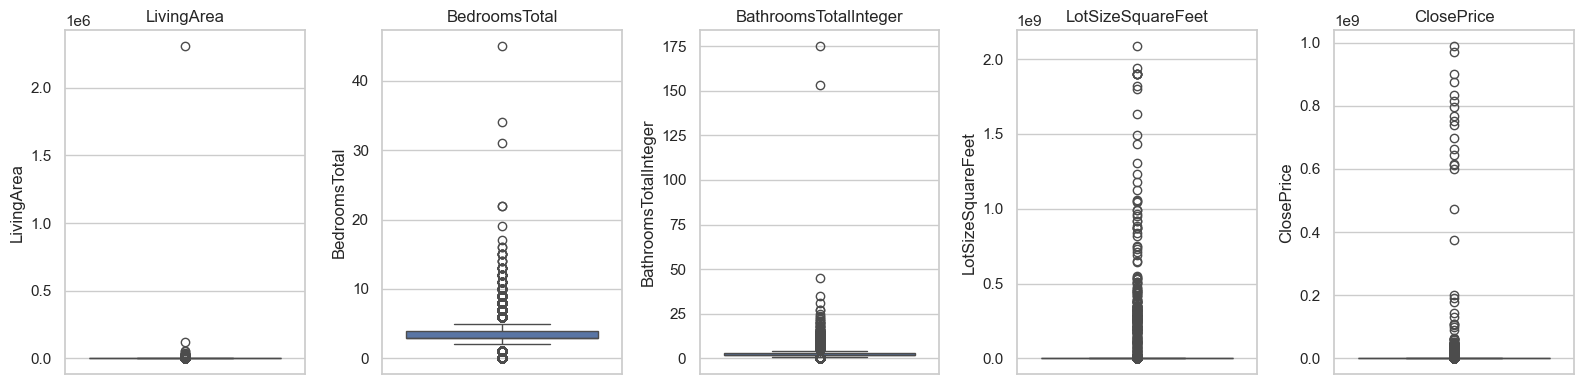

In [18]:
fig, axes = plt.subplots(1, len(feature_cols) + 1, figsize=(16, 4))
for ax, col in zip(axes, feature_cols + ["ClosePrice"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


Flag anything that looks like a data-entry error (e.g. 0-bedroom "single family"
homes, LotSize of 0, ClosePrice near $0 or in the tens of millions) — decide how to
handle these in Week 3, don't drop them yet without a reason.

## 7. Relationship of each feature to ClosePrice

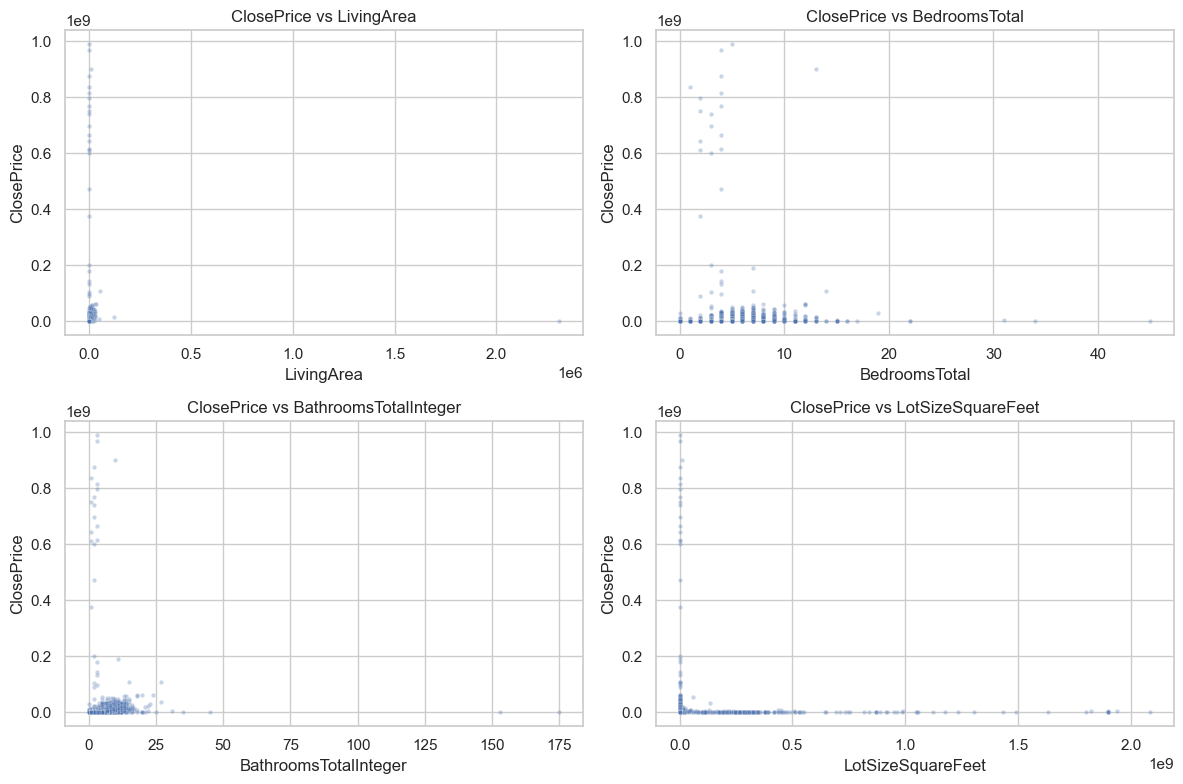

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, feature_cols):
    sns.scatterplot(x=df[col], y=df["ClosePrice"], ax=ax, alpha=0.3, s=10)
    ax.set_title(f"ClosePrice vs {col}")
plt.tight_layout()
plt.show()


## 8. Correlation heatmap (numeric features)

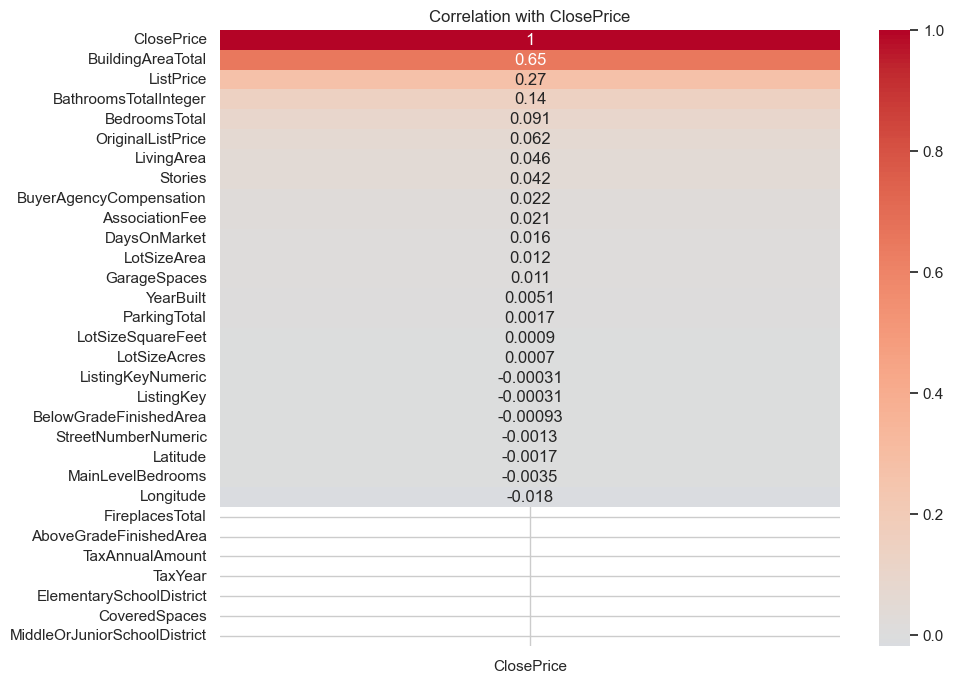

In [23]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr[["ClosePrice"]].sort_values("ClosePrice", ascending=False),
            annot=True, cmap="coolwarm", center=0)
plt.title("Correlation with ClosePrice")
plt.show()


## 9. Sales volume over time (sanity check on the 6-month window)

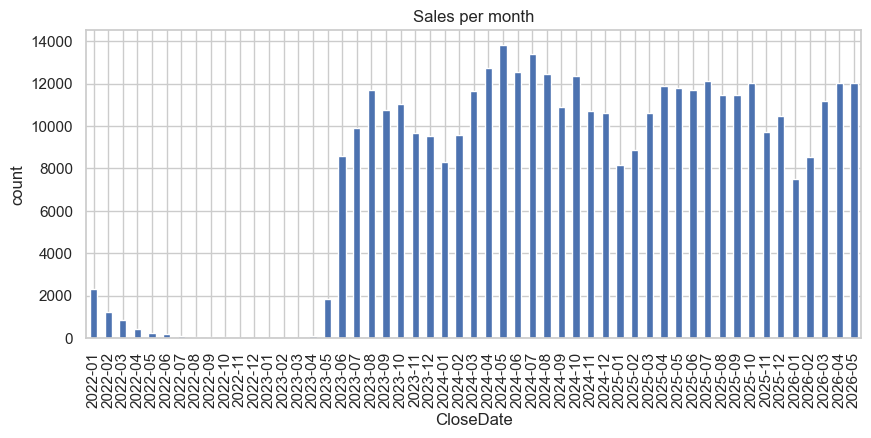

In [25]:
# Adjust to your actual close-date column name, e.g. CloseDate
df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
monthly_counts = df["CloseDate"].dt.to_period("M").value_counts().sort_index()

monthly_counts.plot(kind="bar", figsize=(10, 4), title="Sales per month")
plt.ylabel("count")
plt.show()


## 10. Notes / findings (fill in as you go)

- Target skew: ...
- Missingness worth addressing in Week 3: ...
- Outliers/data-quality issues spotted: ...
- Features that look most predictive so far: ...
- Anything odd about the monthly volume (e.g. a partial month at the edges of your
  download window that you may need to trim before the train/test split): ...
